In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/cleaned_mental_health_data.csv')

In [5]:
'''
numeric_cols = [
    "Age", "Work_Hours_Per_Week", "Sleep_Hours_Night",
    "Caffeine_Drinks_Day", "Screen_Time_Hours_Day",
    "Social_Media_Hours_Day", "Hobby_Time_Hours_Week", "Close_Friends_Count",
]

scale_cols = [
    "Job_Satisfaction", "Work_Stress_Level", "Work_Life_Balance",
    "Financial_Stress", "Social_Support",
    "Feeling_Sad_Down", "Loss_Of_Interest", "Sleep_Trouble",
    "Fatigue", "Poor_Appetite_Or_Overeating", "Feeling_Worthless",
    "Concentration_Difficulty", "Anxious_Nervous", "Mood_Swings",
    "Irritability", "Obsessive_Thoughts", "Compulsive_Behavior",
    "Panic_Attacks", "Feel_Understood", "Loneliness",
]

cat_cols = [
    "Gender", "Income_Level", "Marital_Status", "Remote_Work",
    "Alcohol_Frequency", "Diet_Quality", "Smoking",
    "Company_Mental_Health_Support", "Discuss_Mental_Health",
]

binary_cols = [
    "Ever_Bullied_At_Work", "Self_Harm_Thoughts", "Suicidal_Thoughts",
    "Family_History_Mental_Illness", "Previously_Diagnosed",
    "Ever_Sought_Treatment", "On_Therapy_Now", "On_Medication",
    "Trauma_History", "Has_Mental_Health_Issue",
]
'''

'\nnumeric_cols = [\n    "Age", "Work_Hours_Per_Week", "Sleep_Hours_Night",\n    "Caffeine_Drinks_Day", "Screen_Time_Hours_Day",\n    "Social_Media_Hours_Day", "Hobby_Time_Hours_Week", "Close_Friends_Count",\n]\n\nscale_cols = [\n    "Job_Satisfaction", "Work_Stress_Level", "Work_Life_Balance",\n    "Financial_Stress", "Social_Support",\n    "Feeling_Sad_Down", "Loss_Of_Interest", "Sleep_Trouble",\n    "Fatigue", "Poor_Appetite_Or_Overeating", "Feeling_Worthless",\n    "Concentration_Difficulty", "Anxious_Nervous", "Mood_Swings",\n    "Irritability", "Obsessive_Thoughts", "Compulsive_Behavior",\n    "Panic_Attacks", "Feel_Understood", "Loneliness",\n]\n\ncat_cols = [\n    "Gender", "Income_Level", "Marital_Status", "Remote_Work",\n    "Alcohol_Frequency", "Diet_Quality", "Smoking",\n    "Company_Mental_Health_Support", "Discuss_Mental_Health",\n]\n\nbinary_cols = [\n    "Ever_Bullied_At_Work", "Self_Harm_Thoughts", "Suicidal_Thoughts",\n    "Family_History_Mental_Illness", "Previously_

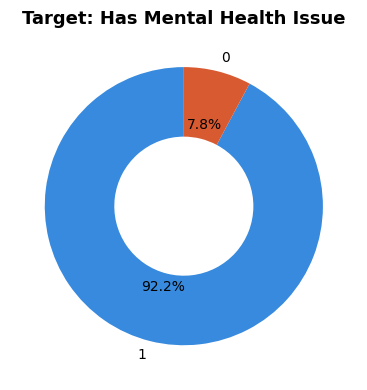

In [6]:
plt.figure(figsize=(5, 4))
vc = df["Has_Mental_Health_Issue"].value_counts()
plt.pie(vc, labels=vc.index, autopct="%1.1f%%",
        colors=["#378ADD", "#D85A30"],
        wedgeprops=dict(width=0.5), startangle=90)
plt.title("Target: Has Mental Health Issue", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

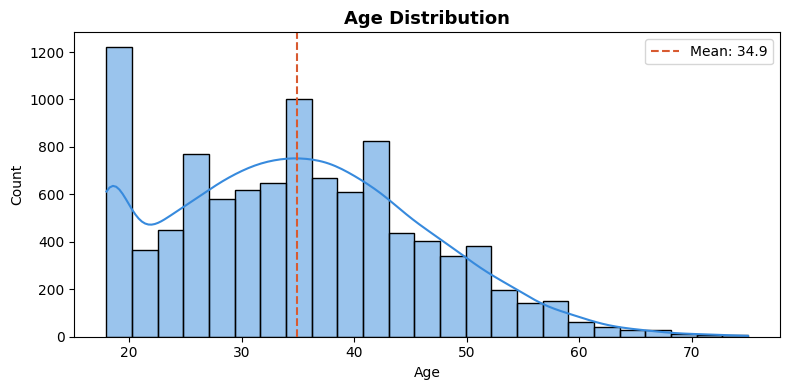

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=25, color="#378ADD", kde=True)
plt.axvline(df["Age"].mean(), color="#D85A30", linestyle="--", label=f'Mean: {df["Age"].mean():.1f}')
plt.title("Age Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

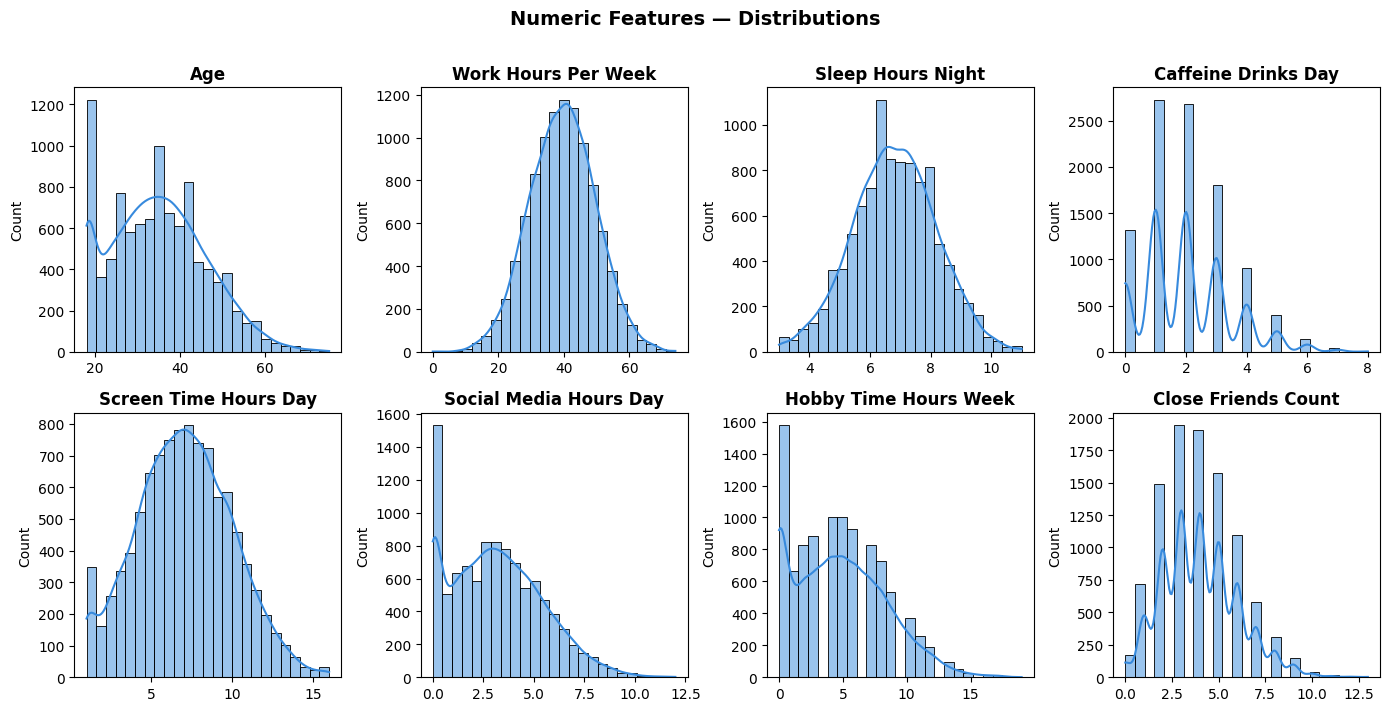

In [8]:
numeric_cols = ["Age", "Work_Hours_Per_Week", "Sleep_Hours_Night",
                "Caffeine_Drinks_Day", "Screen_Time_Hours_Day",
                "Social_Media_Hours_Day", "Hobby_Time_Hours_Week", "Close_Friends_Count"]

existing = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(existing):
    sns.histplot(df[col], bins=25, kde=True, color="#378ADD", ax=axes[i])
    axes[i].set_title(col.replace("_", " "), fontweight="bold")
    axes[i].set_xlabel("")

for j in range(len(existing), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Features — Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

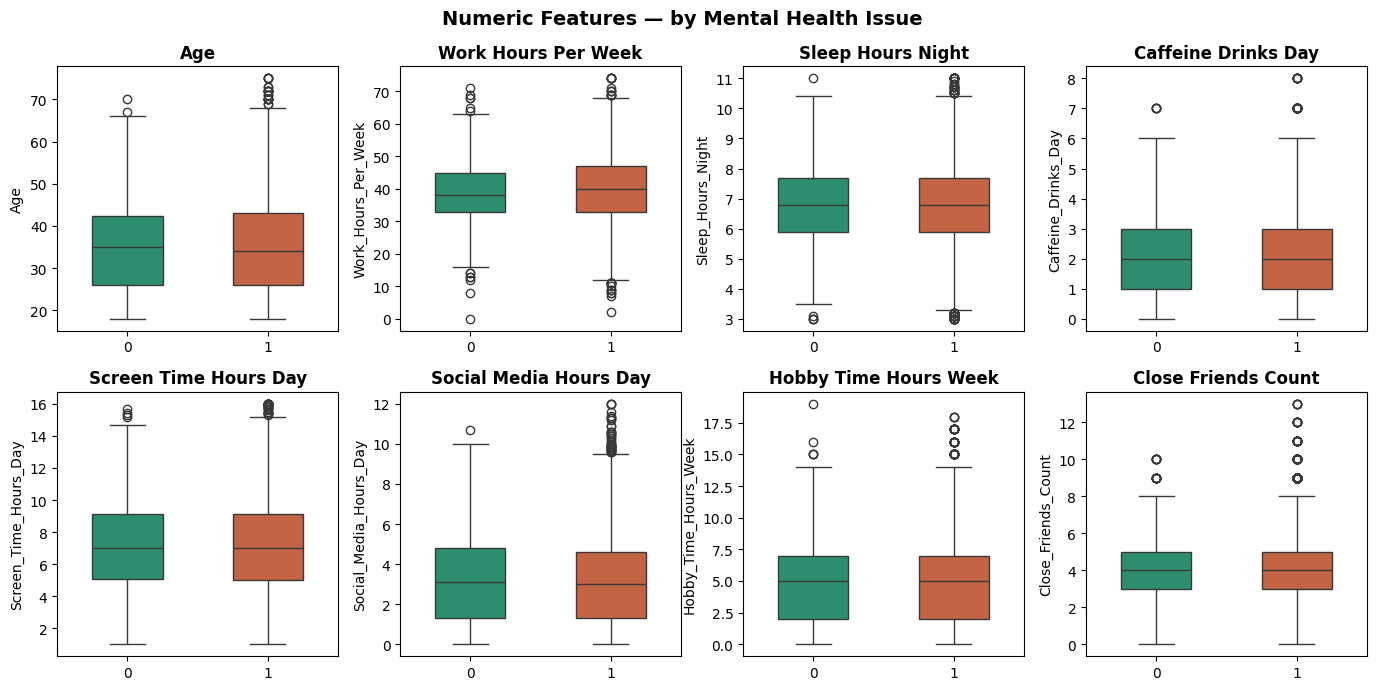

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(existing):
    sns.boxplot(data=df, x="Has_Mental_Health_Issue", y=col,
                hue="Has_Mental_Health_Issue", palette={1: "#D85A30", 0: "#1D9E75"},
                width=0.5, ax=axes[i], legend=False)
    axes[i].set_title(col.replace("_", " "), fontweight="bold")
    axes[i].set_xlabel("")

for j in range(len(existing), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Features — by Mental Health Issue", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_13014/1374056988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order,
/tmp/ipykernel_13014/1374056988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order,
/tmp/ipykernel_13014/1374056988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order,
/tmp/ipykernel_13014/1374056988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

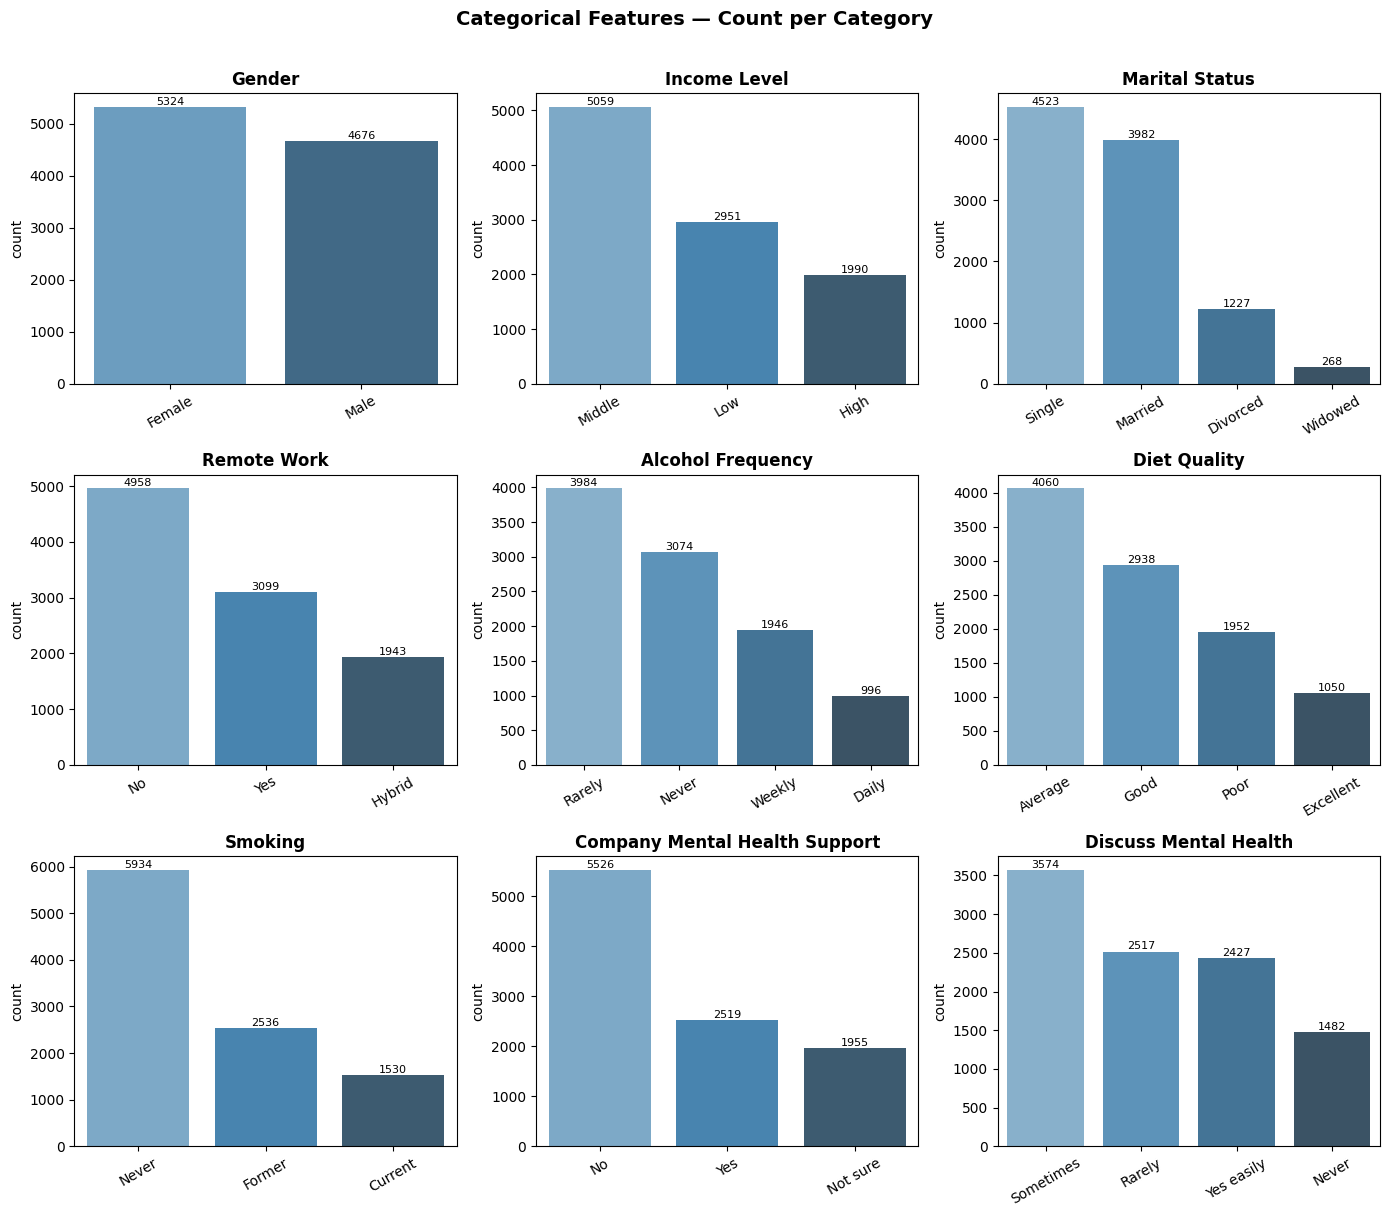

In [10]:
cat_cols = ["Gender", "Income_Level", "Marital_Status", "Remote_Work",
            "Alcohol_Frequency", "Diet_Quality", "Smoking",
            "Company_Mental_Health_Support", "Discuss_Mental_Health"]

existing_cat = [c for c in cat_cols if c in df.columns]
n = len(existing_cat)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(14, ((n + 2) // 3) * 4))
axes = axes.flatten()

for i, col in enumerate(existing_cat):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order,
                  palette="Blues_d", ax=axes[i])
    axes[i].set_title(col.replace("_", " "), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     int(bar.get_height()),
                     ha="center", va="bottom", fontsize=8)

for j in range(len(existing_cat), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Features — Count per Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


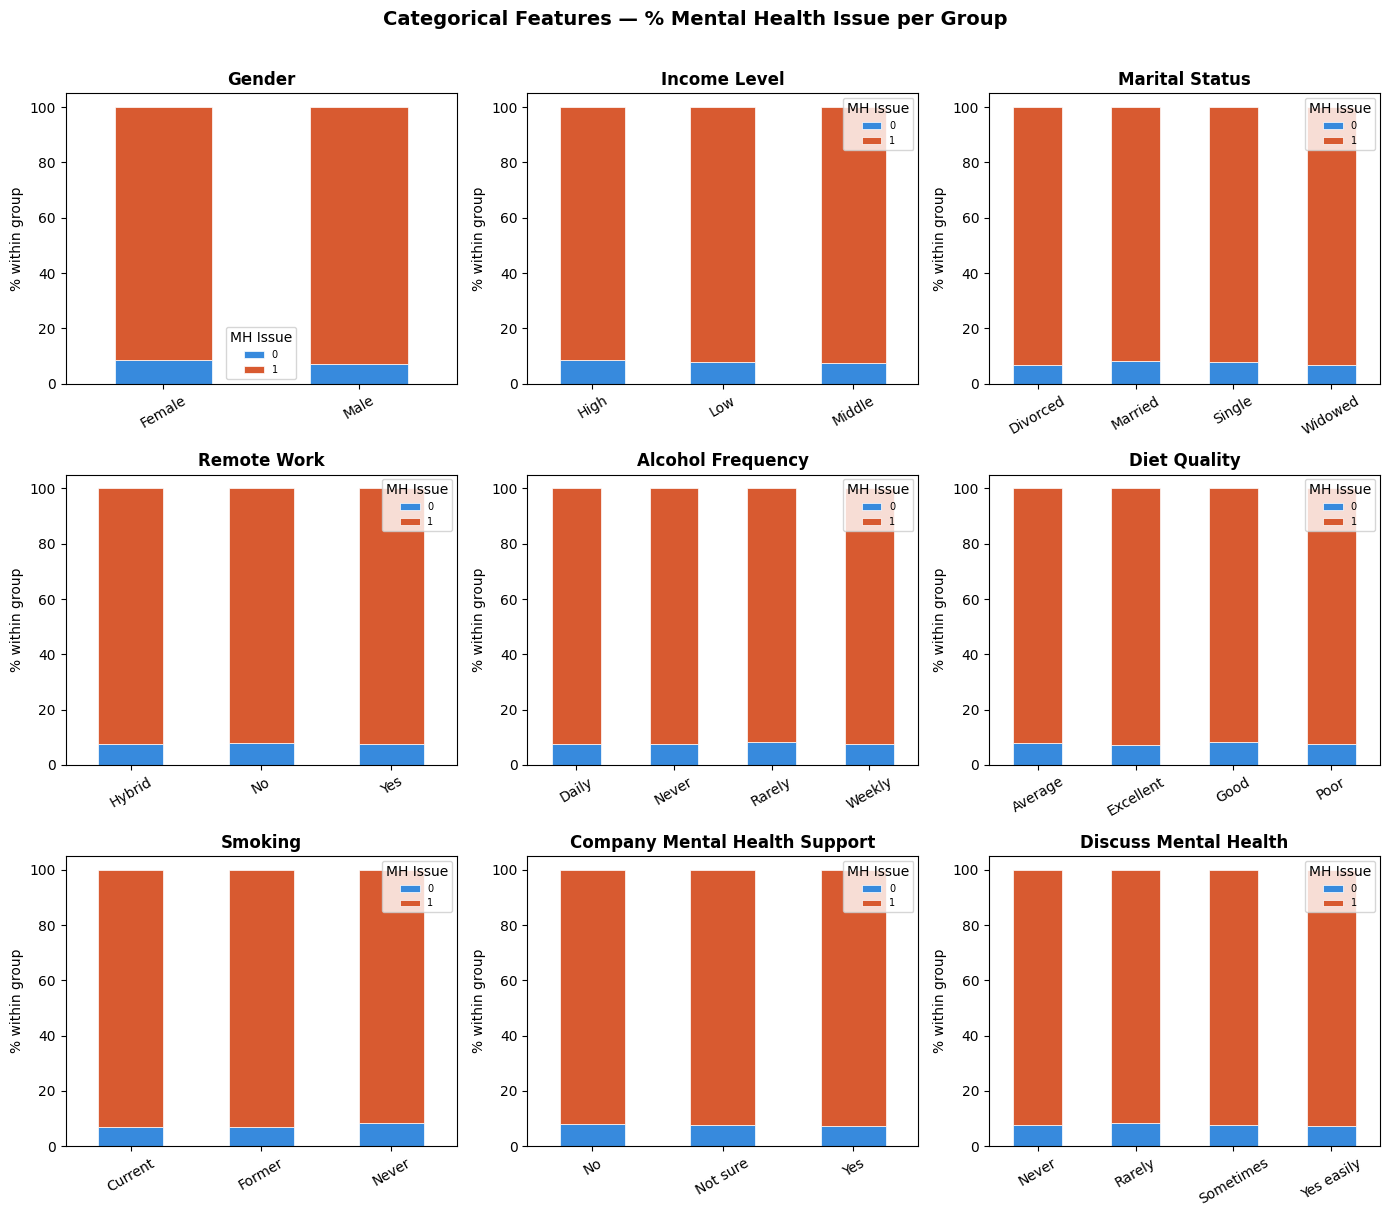

In [11]:
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(14, ((n + 2) // 3) * 4))
axes = axes.flatten()

for i, col in enumerate(existing_cat):
    ct = pd.crosstab(df[col], df["Has_Mental_Health_Issue"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["#378ADD", "#D85A30"], edgecolor="white", linewidth=0.5)
    axes[i].set_title(col.replace("_", " "), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% within group")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="MH Issue", fontsize=7)

for j in range(len(existing_cat), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Features — % Mental Health Issue per Group",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

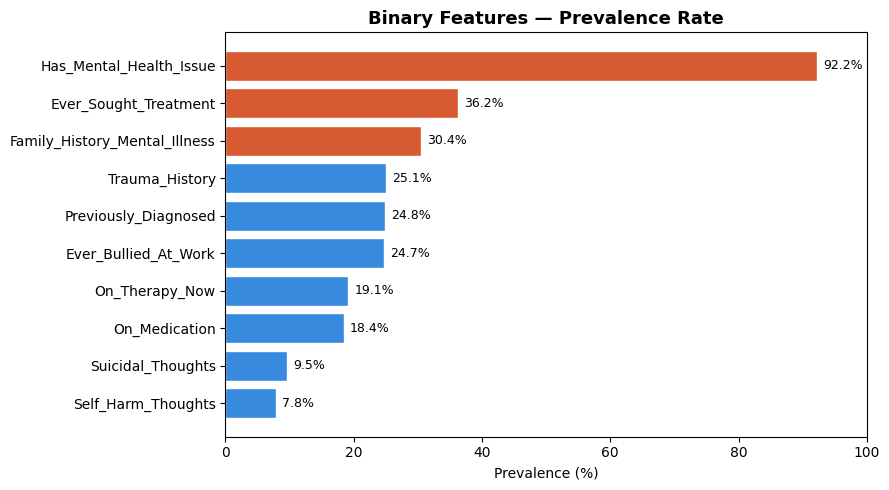

In [12]:
binary_cols = ["Ever_Bullied_At_Work", "Self_Harm_Thoughts", "Suicidal_Thoughts",
               "Family_History_Mental_Illness", "Previously_Diagnosed",
               "Ever_Sought_Treatment", "On_Therapy_Now", "On_Medication",
               "Trauma_History", "Has_Mental_Health_Issue"]

existing_bin = [c for c in binary_cols if c in df.columns]

bin_df = df[existing_bin].apply(
    lambda s: pd.to_numeric(s.map({"Yes": 1, "No": 0, True: 1, False: 0, 1: 1, 0: 0}),
                             errors="coerce"))
prev = (bin_df.mean() * 100).sort_values()

plt.figure(figsize=(9, 5))
colors = ["#D85A30" if v >= 30 else "#378ADD" for v in prev.values]
bars = plt.barh(prev.index, prev.values, color=colors, edgecolor="white")
plt.xlabel("Prevalence (%)")
plt.title("Binary Features — Prevalence Rate", fontsize=13, fontweight="bold")
plt.xlim(0, 100)
for bar, val in zip(bars, prev.values):
    plt.text(val + 1, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

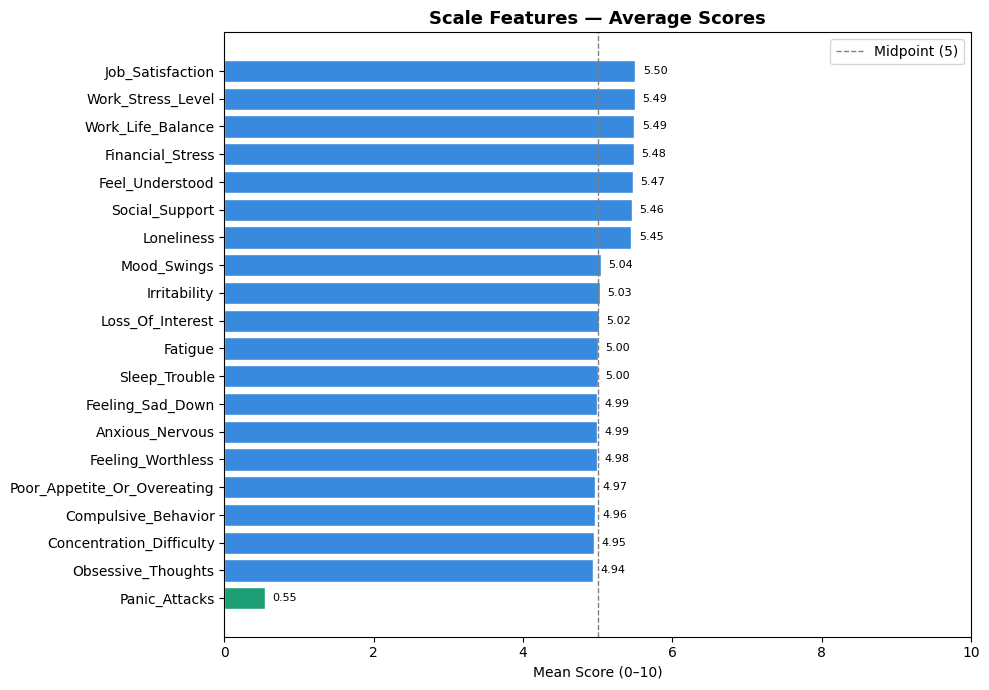

In [13]:
scale_cols = ["Job_Satisfaction", "Work_Stress_Level", "Work_Life_Balance",
              "Financial_Stress", "Social_Support", "Feeling_Sad_Down",
              "Loss_Of_Interest", "Sleep_Trouble", "Fatigue",
              "Poor_Appetite_Or_Overeating", "Feeling_Worthless",
              "Concentration_Difficulty", "Anxious_Nervous", "Mood_Swings",
              "Irritability", "Obsessive_Thoughts", "Compulsive_Behavior",
              "Panic_Attacks", "Feel_Understood", "Loneliness"]

existing_scale = [c for c in scale_cols if c in df.columns]
means = df[existing_scale].mean().sort_values()

plt.figure(figsize=(10, 7))
colors = ["#D85A30" if v >= 6 else "#378ADD" if v >= 4 else "#1D9E75" for v in means.values]
bars = plt.barh(means.index, means.values, color=colors, edgecolor="white")
plt.axvline(5, color="gray", linestyle="--", linewidth=1, label="Midpoint (5)")
plt.xlabel("Mean Score (0–10)")
plt.title("Scale Features — Average Scores", fontsize=13, fontweight="bold")
plt.xlim(0, 10)
for bar, val in zip(bars, means.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

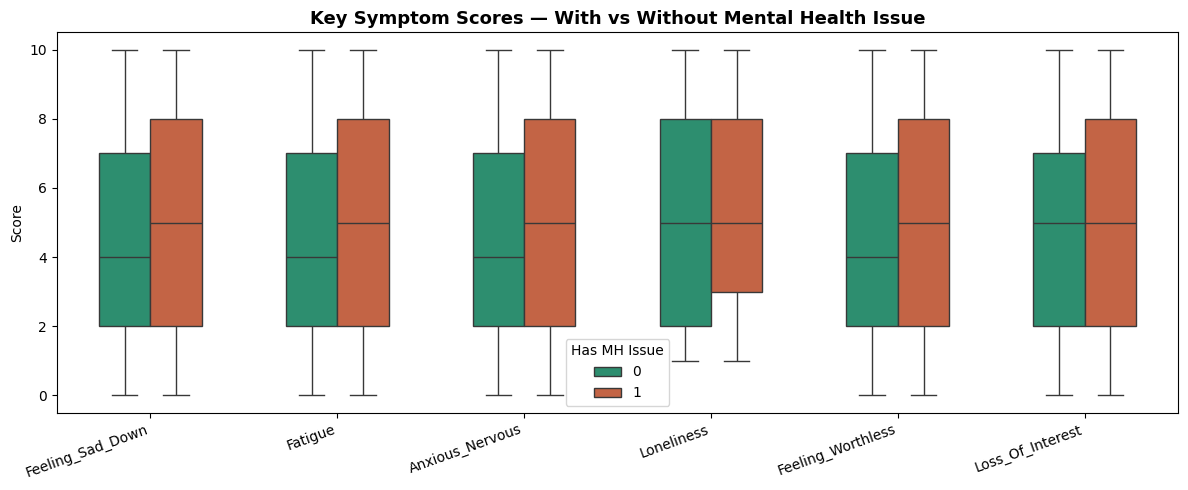

In [14]:

symptom_cols = [c for c in ["Feeling_Sad_Down", "Fatigue", "Anxious_Nervous",
                              "Loneliness", "Feeling_Worthless", "Loss_Of_Interest"]
                if c in df.columns]

melted = df[symptom_cols + ["Has_Mental_Health_Issue"]].melt(
    id_vars="Has_Mental_Health_Issue", var_name="Symptom", value_name="Score")

plt.figure(figsize=(12, 5))
sns.boxplot(data=melted, x="Symptom", y="Score",
            hue="Has_Mental_Health_Issue",
            palette={1: "#D85A30", 0: "#1D9E75"},
            width=0.55)
plt.xticks(rotation=20, ha="right")
plt.title("Key Symptom Scores — With vs Without Mental Health Issue",
          fontsize=13, fontweight="bold")
plt.xlabel("")
plt.legend(title="Has MH Issue")
plt.tight_layout()
plt.show()


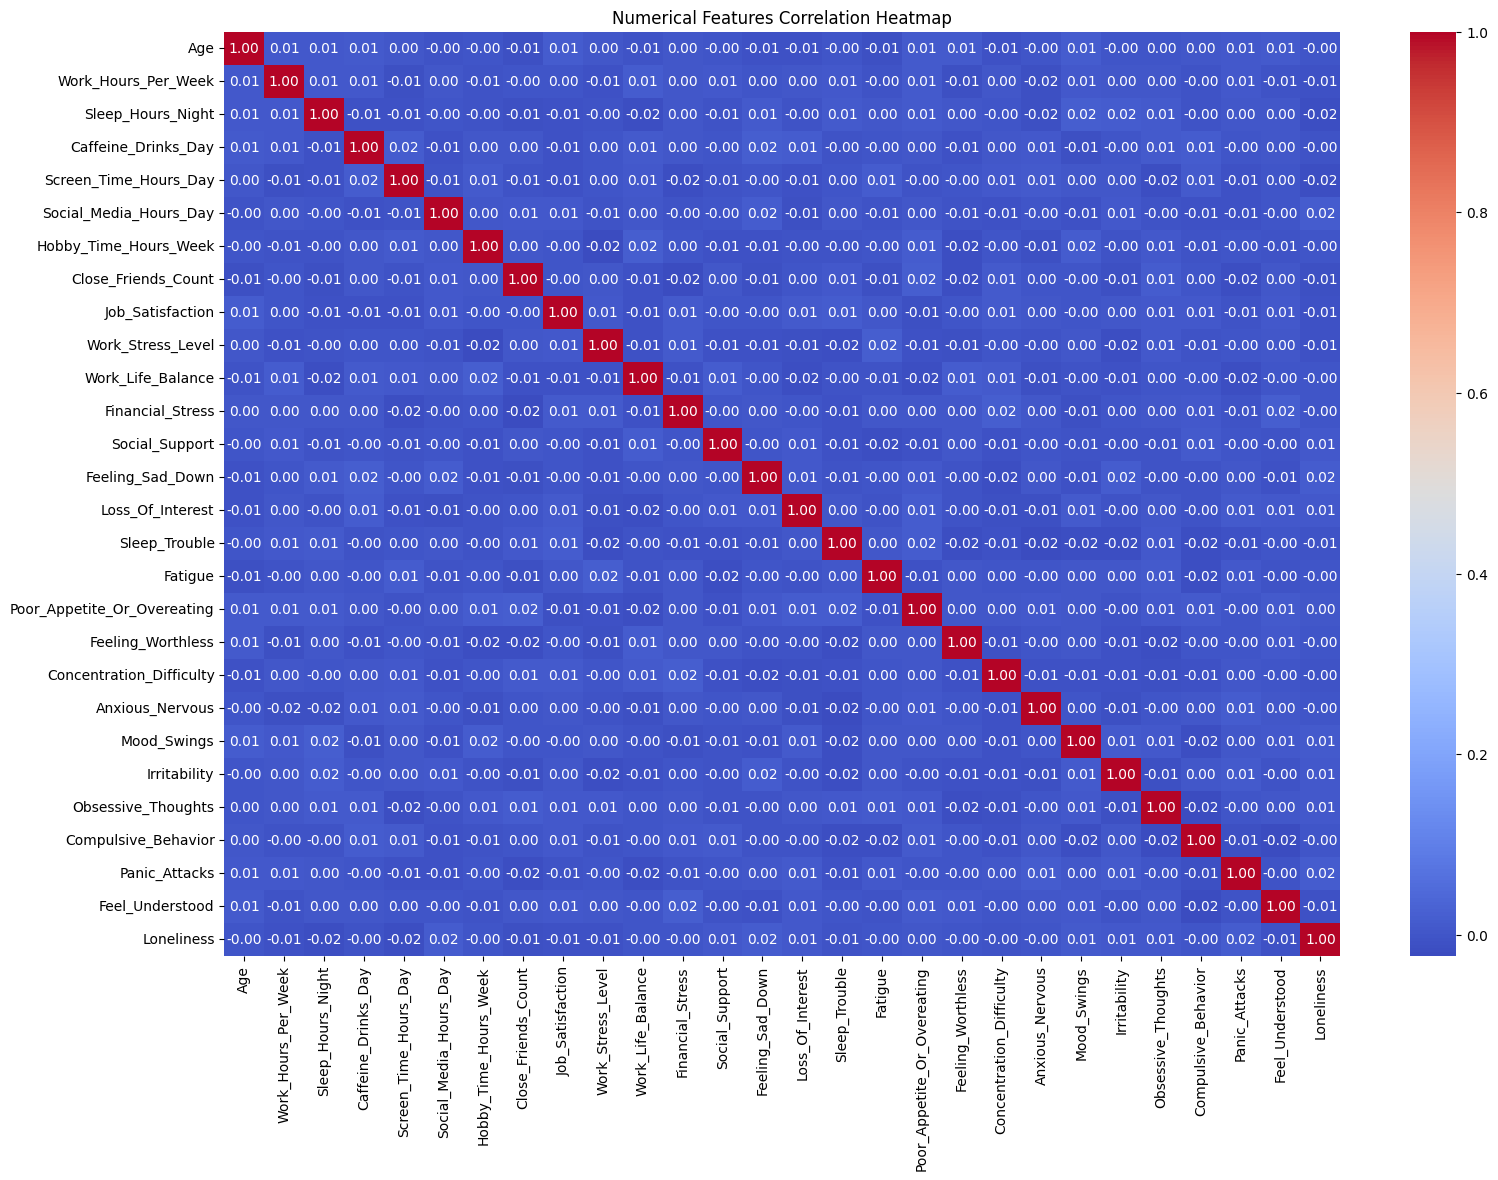

In [16]:
# Numerical columns only
heatmap_cols = numeric_cols + scale_cols

# Correlation matrix
corr_matrix = df[heatmap_cols].corr(method='pearson')

# Plot
plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Features Correlation Heatmap")

plt.show()

In [17]:
from scipy.stats import pointbiserialr

target = "Has_Mental_Health_Issue"

print("Point-Biserial Correlation:\n")

for col in numeric_cols + scale_cols:

    corr, p_value = pointbiserialr(
        df[target],
        df[col]
    )

    print(f"{col}:")
    print(f"Correlation = {corr:.3f}")
    print(f"P-value = {p_value:.5f}")
    print("------")

Point-Biserial Correlation:

Age:
Correlation = 0.001
P-value = 0.88822
------
Work_Hours_Per_Week:
Correlation = 0.021
P-value = 0.03795
------
Sleep_Hours_Night:
Correlation = 0.002
P-value = 0.82874
------
Caffeine_Drinks_Day:
Correlation = -0.006
P-value = 0.51921
------
Screen_Time_Hours_Day:
Correlation = -0.001
P-value = 0.91719
------
Social_Media_Hours_Day:
Correlation = -0.009
P-value = 0.36650
------
Hobby_Time_Hours_Week:
Correlation = 0.009
P-value = 0.37068
------
Close_Friends_Count:
Correlation = -0.003
P-value = 0.76770
------
Job_Satisfaction:
Correlation = -0.024
P-value = 0.01650
------
Work_Stress_Level:
Correlation = 0.055
P-value = 0.00000
------
Work_Life_Balance:
Correlation = 0.009
P-value = 0.38121
------
Financial_Stress:
Correlation = 0.046
P-value = 0.00000
------
Social_Support:
Correlation = -0.048
P-value = 0.00000
------
Feeling_Sad_Down:
Correlation = 0.050
P-value = 0.00000
------
Loss_Of_Interest:
Correlation = 0.020
P-value = 0.04299
------
Sleep_T

In [18]:
from scipy.stats import chi2_contingency

target = "Has_Mental_Health_Issue"

print("Chi-Square Test:\n")

for col in cat_cols:

    contingency_table = pd.crosstab(
        df[col],
        df[target]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    print(f"{col}:")
    print(f"Chi2 Statistic = {chi2:.3f}")
    print(f"P-value = {p:.5f}")
    print("------")

Chi-Square Test:

Gender:
Chi2 Statistic = 5.728
P-value = 0.01670
------
Income_Level:
Chi2 Statistic = 2.147
P-value = 0.34176
------
Marital_Status:
Chi2 Statistic = 2.385
P-value = 0.49647
------
Remote_Work:
Chi2 Statistic = 1.248
P-value = 0.53581
------
Alcohol_Frequency:
Chi2 Statistic = 1.036
P-value = 0.79257
------
Diet_Quality:
Chi2 Statistic = 1.545
P-value = 0.67195
------
Smoking:
Chi2 Statistic = 4.750
P-value = 0.09303
------
Company_Mental_Health_Support:
Chi2 Statistic = 1.155
P-value = 0.56140
------
Discuss_Mental_Health:
Chi2 Statistic = 1.621
P-value = 0.65467
------
